# Lab 04: Learning Curves, Cross-Validation, and Model Generalization

Welcome to Lab 04! In this laboratory, you will explore how machine learning models generalize to unseen data, how to diagnose model performance issues like **underfitting** and **overfitting**, and how to use **learning curves** and **cross-validation** to build more robust models.

## Learning Objectives
By the end of this lab, you will be able to:
1. Define and interpret **learning curves** (training error vs. validation error as data size increases).
2. Diagnose **underfitting** and **overfitting** by examining error trends and gaps.
3. Understand why training error alone is insufficient for evaluating model quality.
4. Implement and interpret **K-Fold Cross-Validation** using scikit-learn.
5. Use scikit-learn's built-in `learning_curve` utility to visualize model performance.
6. Apply cross-validation principles to hyperparameter selection while safeguarding against data leakage.

## 0 Setup and Libraries

We import the essential libraries needed for numerical operations, data generation, modeling, and visualization, and set up our custom styling and color palette.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import make_regression

In [2]:
# Class palette: colors are part of the pedagogy
C = dict(bg="#0D1520", panel="#152232", grid="#26384D", text="#E8EEF4", sec="#9DB2C6",
            data="#E879F9",   # real data
            x="#3499CF",      # original X
            x2="#22D3EE",     # X²
            x3="#A78BFA",     # X³
            lin="#F05133",    # linear regression (straight line)
            poly="#4ADE80",   # polynomial regression (curve)
            deg="#FBBF24",    # degree / hyperparameter
            err="#F87171")    # error / residuals

plt.rcParams.update({
    "figure.facecolor": C["bg"], "axes.facecolor": C["panel"], "axes.edgecolor": C["grid"],
    "axes.labelcolor": C["sec"], "xtick.color": C["sec"], "ytick.color": C["sec"],
    "text.color": C["text"], "grid.color": C["grid"], "axes.grid": True, "grid.alpha": 0.6,
    "legend.facecolor": C["panel"], "legend.edgecolor": C["grid"], "font.size": 11,
    "axes.titleweight": "bold", "figure.dpi": 110,
})

RNG = np.random.default_rng(42)
print("scikit-learn and environment ready, fixed seed = 42")

scikit-learn and environment ready, fixed seed = 42


## 1 Introduction to Learning Curves

A **learning curve** is a graph that illustrates how a model's performance changes as the amount of **training data increases**. It is one of the most practical diagnostic tools for understanding whether a model suffers from high bias (underfitting) or high variance (overfitting).
 
- **Training Error:** The error measured on the exact data used to train the model.
- **Validation Error:** The error measured on unseen data (held-out validation split or cross-validation folds).
- **Evaluation Metrics:** For regression tasks, we commonly use Mean Squared Error (MSE) or Root Mean Squared Error (RMSE). For these metrics, **lower values indicate better performance**.

---


## 2 Understanding Underfitting, Overfitting, and Good Fit

To make reliable predictions, we must balance model complexity and data availability:

| Fit Type | Training Error | Validation Error | Diagnostic Signs | Underlying Cause |
| :--- | :--- | :--- | :--- | :--- |
| **Underfitting** | High | High (close to training) | Both errors are high and converge at a high error rate. | Model is too simple to capture patterns in the data. |
| **Overfitting** | Very Low | High (significantly above training) | Noticeable gap between training and validation errors. | Model is too complex and learns random noise/memorizes data. |
| **Good Fit** | Low | Low (close to training) | The two curves converge at a relatively low error level. | Model generalizes well to unseen data. |


> **Important Note:** Learning curve patterns are diagnostic clues rather than absolute mathematical laws. Their interpretation depends heavily on your specific dataset, model family, and evaluation metric.

---

## 3 Why Training Error Is Not Enough

It is tempting to pick the model with the lowest training error, but doing so often leads to poor generalization. A highly complex model can fit training points nearly perfectly—including noise and random fluctuations.

Let's demonstrate this with a synthetic regression dataset.

In [4]:
# Generate synthetic non-linear data with noise
n_samples = 150
X = np.sort(RNG.uniform(0, 10, n_samples))
y = np.sin(X) + RNG.normal(0, 0.3, n_samples)
X_reshaped = X[:, np.newaxis]

X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.3, random_state=42)

In [5]:
# Compare a Simple Model (Linear Regression) vs Overly Complex Model (Degree 15 Polynomial)
lin_reg = Pipeline([('scaler', StandardScaler()), ('regressor', LinearRegression())])
poly_reg = Pipeline([
    ('poly', PolynomialFeatures(degree=15)),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

lin_reg.fit(X_train, y_train)
poly_reg.fit(X_train, y_train)

train_mse_lin = mean_squared_error(y_train, lin_reg.predict(X_train))
test_mse_lin = mean_squared_error(y_test, lin_reg.predict(X_test))

train_mse_poly = mean_squared_error(y_train, poly_reg.predict(X_train))
test_mse_poly = mean_squared_error(y_test, poly_reg.predict(X_test))

print(f"Linear Model  -> Train MSE: {train_mse_lin:.4f} | Test MSE: {test_mse_lin:.4f}")
print(f"Poly 15 Model -> Train MSE: {train_mse_poly:.4f} | Test MSE: {test_mse_poly:.4f}")

Linear Model  -> Train MSE: 0.4834 | Test MSE: 0.6029
Poly 15 Model -> Train MSE: 0.0755 | Test MSE: 0.1368


> Notice how the Degree 15 polynomial achieves an extremely low training error, but its test error skyrockets due to overfitting. This proves why evaluating exclusively on training data is misleading.

---


## 4 Building a Learning Curve from Scratch

Let's construct a learning curve manually to see how training and validation errors evolve as we progressively feed more data to our model.

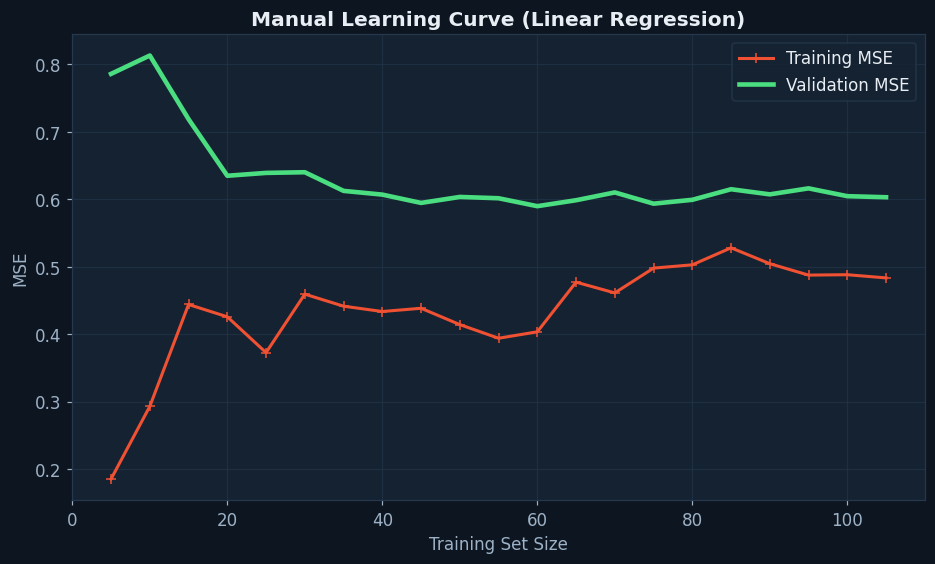

In [6]:
def plot_manual_learning_curve(model, X_train, y_train, X_val, y_val):
    train_errors, val_errors = [], []
    step_sizes = range(5, len(X_train) + 1, 5)
    
    for m in step_sizes:
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))
        
    plt.figure(figsize=(10, 5.5))
    plt.plot(step_sizes, train_errors, "-+", color=C["lin"], linewidth=2, label="Training MSE")
    plt.plot(step_sizes, val_errors, "-", color=C["poly"], linewidth=3, label="Validation MSE")
    plt.xlabel("Training Set Size")
    plt.ylabel("MSE")
    plt.title("Manual Learning Curve (Linear Regression)")
    plt.legend(loc="upper right")
    plt.show()

plot_manual_learning_curve(lin_reg, X_train, y_train, X_test, y_test)

---

## 5 Cross-Validation Fundamentals & Practice

A single train/validation split can produce an unreliable estimate of performance due to luck of the draw. **K-Fold Cross-Validation** resolves this by splitting the training data into $K$ equal folds, training on $K-1$, validating on the remaining fold, and averaging the performance scores across all iterations.

Scikit-learn's `cross_val_score` follows a utility philosophy where higher values are better. Loss metrics like MSE are returned as **negative values** (`neg_mean_squared_error`), which we negate back to positive.

In [7]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    lin_reg,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_mean_squared_error"
)

cv_mse_scores = -cv_scores
print(f"Cross-Validation MSE Scores: {np.round(cv_mse_scores, 4)}")
print(f"Mean CV MSE: {cv_mse_scores.mean():.4f} (+/- {cv_mse_scores.std():.4f})")

Cross-Validation MSE Scores: [0.663  0.3434 0.4604 0.5264 0.4879]
Mean CV MSE: 0.4962 (+/- 0.1034)


---

## 6 Learning Curves with Scikit-Learn (`learning_curve`)

Scikit-learn provides `sklearn.model_selection.learning_curve`, which automates generating training and validation scores across multiple training set sizes with integrated cross-validation.



In [8]:
train_sizes, train_scores, val_scores = learning_curve(
    lin_reg,
    X_reshaped,
    y,
    cv=cv,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="neg_mean_squared_error"
)

train_mse_mean = -train_scores.mean(axis=1)
train_mse_std = -train_scores.std(axis=1)
val_mse_mean = -val_scores.mean(axis=1)
val_mse_std = val_scores.std(axis=1)

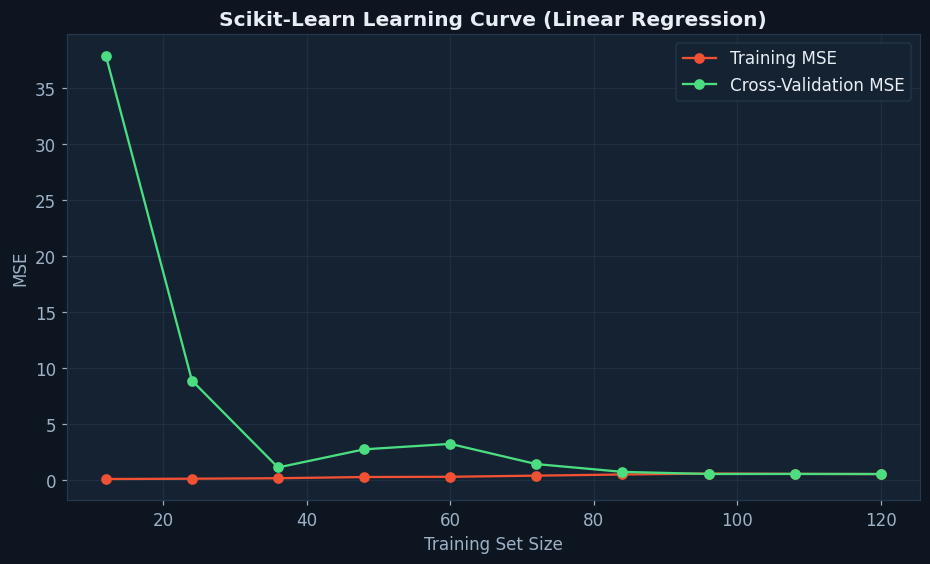

In [9]:
plt.figure(figsize=(10, 5.5))
plt.plot(train_sizes, train_mse_mean, 'o-', color=C["lin"], label="Training MSE")
plt.plot(train_sizes, val_mse_mean, 'o-', color=C["poly"], label="Cross-Validation MSE")

plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.title("Scikit-Learn Learning Curve (Linear Regression)")
plt.legend(loc="upper right")
plt.show()

---

## 7 Using Cross-Validation to Select Hyperparameters

Cross-validation is widely used for hyperparameter tuning. Let's compare polynomial regression models of varying degrees to select the optimal complexity.

In [10]:
degrees = list(range(1, 10))
cv_mean, cv_std = [], []

In [11]:
for deg in degrees:
    model_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ])
    
    scores = -cross_val_score(model_pipeline, X_train, y_train, cv=cv, scoring="neg_mean_squared_error")
    cv_mean.append(scores.mean())
    cv_std.append(scores.std())

In [12]:
results_df = pd.DataFrame({
    "Degree": degrees,
    "CV MSE Mean": np.round(cv_mean, 4),
    "CV MSE Std": np.round(cv_std, 4)
})
print(results_df.to_string(index=False))

 Degree  CV MSE Mean  CV MSE Std
      1       0.4962      0.1034
      2       0.4518      0.1056
      3       0.3966      0.0857
      4       0.1623      0.0654
      5       0.1523      0.0575
      6       0.1072      0.0379
      7       0.1080      0.0336
      8       0.1030      0.0302
      9       0.1068      0.0223


---

## 8 End-to-End Practical Experiment

Let's combine these concepts into an end-to-end experiment using `GridSearchCV` on a generated multi-feature dataset, then evaluate our selected model on the untouched test set.

In [13]:
X_exp, y_exp = make_regression(n_samples=300, n_features=5, noise=1.5, random_state=42)
X_e_train, X_e_test, y_e_train, y_e_test = train_test_split(X_exp, y_exp, test_size=0.2, random_state=42)

experiment_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

In [14]:
experiment_pipeline.fit(X_e_train, y_e_train)
test_mse = mean_squared_error(y_e_test, experiment_pipeline.predict(X_e_test))

print(f"Final Model Evaluation on Untouched Test Set - MSE: {test_mse:.4f}")

Final Model Evaluation on Untouched Test Set - MSE: 2.1936


---
## 9 Exercises

- **Exercise 1:** Modify the pipeline in Section 7 to include polynomial features up to degree `10`. Observe how the cross-validation score shifts and explain whether it exhibits signs of overfitting.

- **Exercise 2:** Re-run the cross-validation in Section 5 using `cv=10` instead of `cv=5`. How do the mean and standard deviation change?